
N_R1s(r) =
+30.8907 * exp(-6.4768 r)
+4.1906 * exp(-11.2837 r)
+0.0014 * r * exp(-1.2856 r)
-0.0056 * r * exp(-1.8521 r)
+0.0919 * r * exp(-3.2043 r)
+0.8604 * r * exp(-5.0912 r)

N_R2s(r) =
-7.2242 * exp(-6.4768 r)
-0.6618 * exp(-11.2837 r)
+0.2533 * r * exp(-1.2856 r)
+3.5466 * r * exp(-1.8521 r)
+7.3459 * r * exp(-3.2043 r)
-9.3696 * r * exp(-5.0912 r)

N_R2p(r) =
+0.3414 * r * exp(-1.0449 r)
+2.0868 * r * exp(-1.6355 r)
+6.0765 * r * exp(-3.0515 r)
+3.0170 * r * exp(-7.5648 r)
Norm 1s = 0.9958912344020423
Norm 2s = 0.9139882340364736
Norm 2p = 1.0689113317747962
           Q  J_1s_one_electron  J_2s_one_electron  J_2p_one_electron  \
0       0.00       1.297259e-01       6.094813e-01       4.353451e-01   
1       0.05       1.297018e-01       6.067136e-01       4.353308e-01   
2       0.10       1.296295e-01       5.985037e-01       4.352060e-01   
3       0.15       1.295091e-01       5.851244e-01       4.347401e-01   
4       0.20       1.293408e-01       5.670100e-01       4.33

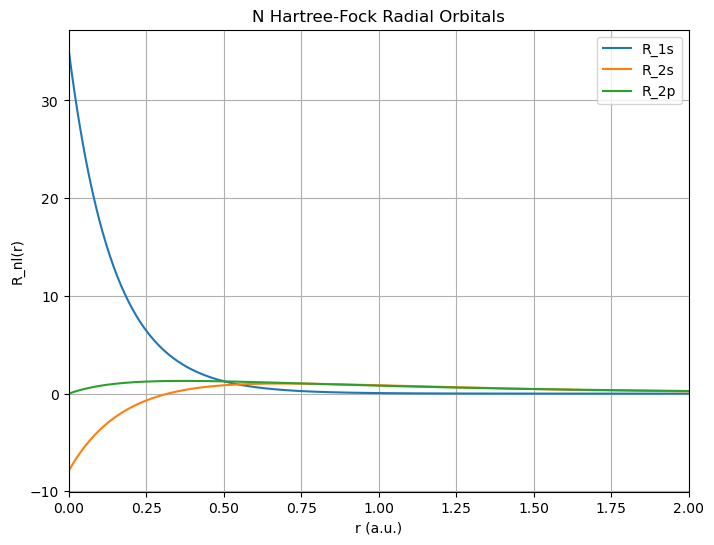

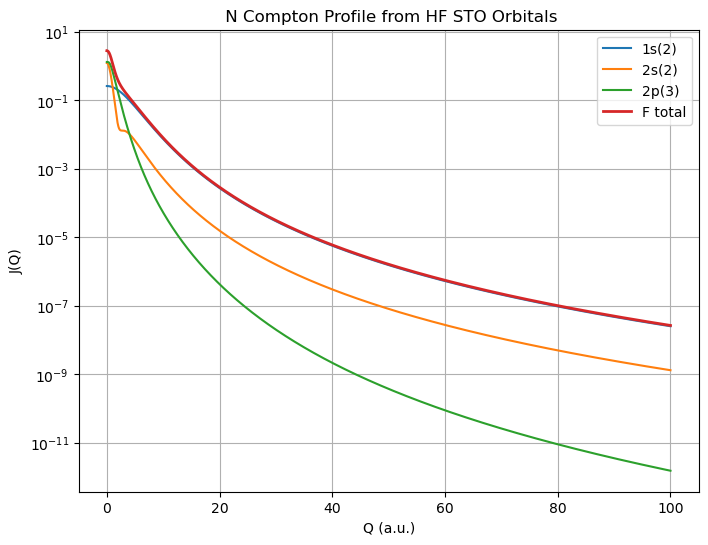

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import spherical_jn, factorial
from scipy.integrate import cumulative_trapezoid

# =====================================================
# Nitrogen Hartree-Fock STO data
# N: 1s2 2s2 2p3
# Ground term: 2p
# Format: (n_j, Z_j, C_j)
# =====================================================

nitrogen_1s = [
    (1,  6.47679,  0.93704),
    (1,  11.28370, 0.05528),
    (2,  1.28558,  0.00063),
    (2,  1.85215, -0.00103),
    (2,  3.20431,  0.00433),
    (2,  5.09120,  0.01274),
]

nitrogen_2s = [
    (1,  6.47679,  -0.21914),
    (1,  11.28370, -0.00873),
    (2,  1.28558,   0.11705),
    (2,  1.85215,   0.65789),
    (2,  3.20431,   0.34613),
    (2,  5.09120,  -0.13874),
]

nitrogen_2p = [
    (2, 1.04491, 0.26490),
    (2, 1.63553, 0.52829),
    (2, 3.05150, 0.32352),
    (2, 7.56484, 0.01660),
   ]
# =====================================================
# HF normalization constant
# N_j = sqrt((2Z)^(2n+1)/(2n)!)
# =====================================================
def N_sto(n, Z):
    return np.sqrt((2*Z)**(2*n + 1) / factorial(2*n, exact=False))

def R_nl(r, coeffs):
    R = np.zeros_like(r)
    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        R += C * N * r**(n-1) * np.exp(-Z*r)
    return R
# =====================================================
# Grids
# =====================================================

r = np.linspace(1e-6, 60.0, 20000)     # radial grid
p = np.arange(0.0, 1000.0 + 0.05, 0.05) # momentum grid
Q = np.arange(0.0, 100.0 + 0.05, 0.05) # Q grid

# =====================================================
# Calculate chi_nl(p)
# chi_nl(p) = sqrt(2/pi) int R_nl(r) j_l(pr) r^2 dr
# =====================================================

def chi_p(p_grid, r_grid, R_grid, l):
    chi = []

    for pp in p_grid:
        jl = spherical_jn(l, pp*r_grid)
        integrand = R_grid * jl * r_grid**2
        val = np.sqrt(2/np.pi) * np.trapezoid(integrand, r_grid)
        chi.append(val)

    return np.array(chi)

# =====================================================
# Calculate J(Q)
# I(p) = |chi(p)|^2 p^2
# J(Q) = 1/2 int_Q^inf I(p)/p dp
# =====================================================

def calculate_J(p_grid, chi_grid, Q_grid):
    I = chi_grid**2 * p_grid**2

    integrand = np.zeros_like(p_grid)
    integrand[1:] = I[1:] / p_grid[1:]

    # Reverse cumulative integral from p to infinity
    rev_integral = cumulative_trapezoid(
        integrand[::-1],
        p_grid[::-1],
        initial=0
    )

    J_p = -0.5 * rev_integral[::-1]

    # Interpolate J from p-grid to Q-grid
    J_Q = np.interp(Q_grid, p_grid, J_p)

    return I, J_Q

# =====================================================
# Build Nitrogen radial orbitals
# =====================================================
def print_R_formula(coeffs, name):
    print(f"\n{name}(r) =")

    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        A = C * N

        if n == 1:
            print(f"{A:+.4f} * exp(-{Z:.4f} r)")
        elif n == 2:
            print(f"{A:+.4f} * r * exp(-{Z:.4f} r)")
        elif n == 3:
            print(f"{A:+.4f} * r^2 * exp(-{Z:.4f} r)")
        elif n == 4:
            print(f"{A:+.4f} * r^3 * exp(-{Z:.4f} r)")
            
R1s = R_nl(r, nitrogen_1s)
R2s = R_nl(r, nitrogen_2s)
R2p = R_nl(r, nitrogen_2p)

print_R_formula(nitrogen_1s, "N_R1s")
print_R_formula(nitrogen_2s, "N_R2s")
print_R_formula(nitrogen_2p, "N_R2p")

# =====================================================
# Momentum-space wavefunctions
# =====================================================

chi_1s = chi_p(p, r, R1s, l=0)
chi_2s = chi_p(p, r, R2s, l=0)
chi_2p = chi_p(p, r, R2p, l=1)


# =====================================================
# Momentum densities and Compton profiles
# =====================================================
I_1s, J_1s = calculate_J(p, chi_1s, Q)
I_2s, J_2s = calculate_J(p, chi_2s, Q)
I_2p, J_2p = calculate_J(p, chi_2p, Q)

print("Norm 1s =", np.trapezoid(I_1s, p))
print("Norm 2s =", np.trapezoid(I_2s, p))
print("Norm 2p =", np.trapezoid(I_2p, p))

# N: 1s2 2s2 2p3
J_total = 2*J_1s + 2*J_2s + 3*J_2p   

# =====================================================
# Print and save table
# =====================================================
table = pd.DataFrame({
    "Q": Q,
    "J_1s_one_electron": J_1s,
    "J_2s_one_electron": J_2s,
    "J_2p_one_electron": J_2p,
    "J_total_N": J_total
    })
print(table)
table.to_csv("N_HF_profile.csv", index = False)

# =====================================================
# Plot radial orbitals
# =====================================================

plt.figure(figsize=(8,6))
plt.plot(r, R1s, label="R_1s")
plt.plot(r, R2s, label="R_2s")
plt.plot(r, R2p, label="R_2p")
plt.xlim(0, 2)
plt.xlabel("r (a.u.)")
plt.ylabel("R_nl(r)")
plt.title("N Hartree-Fock Radial Orbitals")
plt.grid(True)
plt.legend()
plt.show()

# =====================================================
# Plot Compton profiles
# =====================================================
plt.figure(figsize=(8,6))
plt.plot(Q, 2*J_1s, label="1s(2)")
plt.plot(Q, 2*J_2s, label="2s(2)")
plt.plot(Q, 3*J_2p, label="2p(3)")

plt.plot(Q, J_total, label="F total", linewidth=2)

plt.xlabel("Q (a.u.)")
plt.ylabel("J(Q)")
plt.title(" N Compton Profile from HF STO Orbitals")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()